In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#import warnings
#warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


(891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


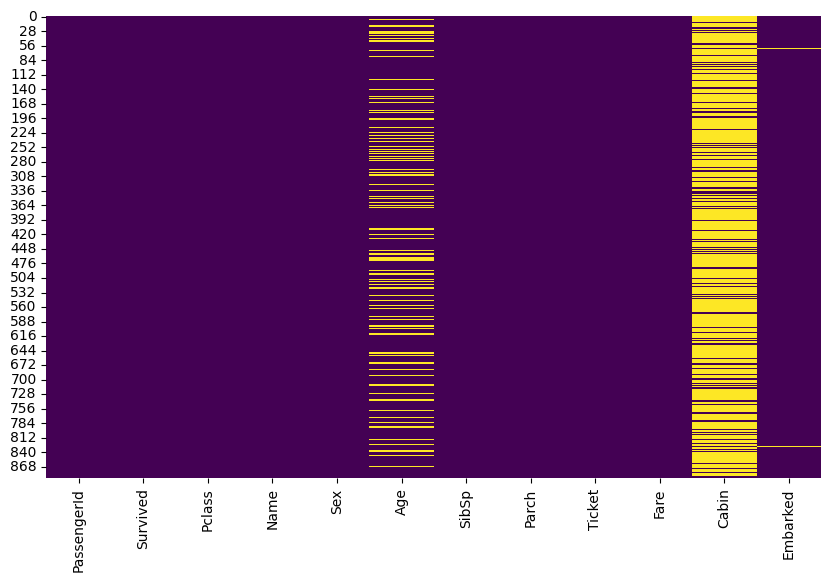

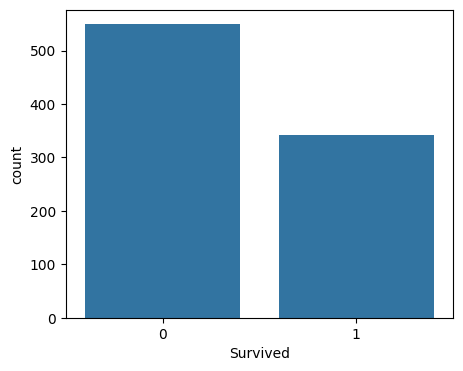

Survived
0    549
1    342
Name: count, dtype: int64


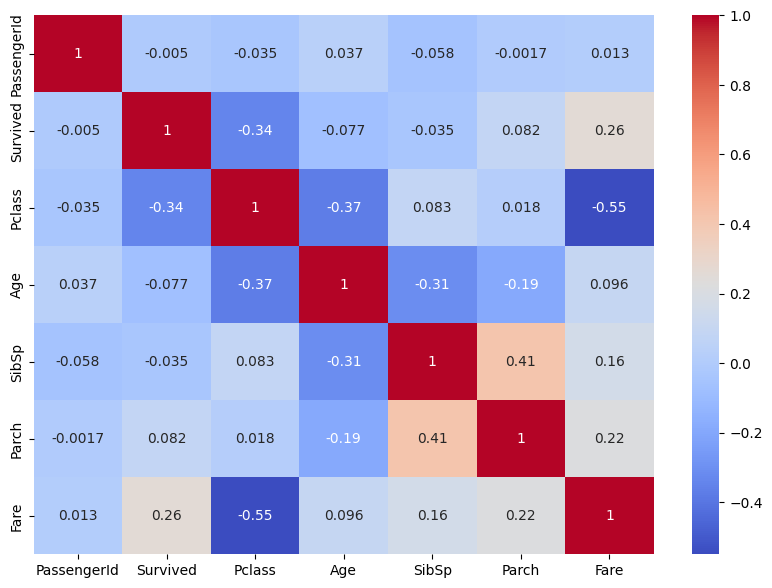

In [4]:
print(df.shape)
df.info()
miss = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})
miss
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.show()
plt.figure(figsize=(5,4))
sns.countplot(x="Survived", data=df)
plt.show()
print(df["Survived"].value_counts())
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [6]:
numerical_cols = df.select_dtypes(include=["int64","float64"]).columns
categorical_cols = df.select_dtypes(include="object").columns

print(numerical_cols)
print(categorical_cols)
df["Age"].fillna(df["Age"].median(), inplace=True)
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)
df.drop("Cabin", axis=1, inplace=True)
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
df["Title"] = df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)

df["Title"] = df["Title"].replace(
    ["Lady","Countess","Capt","Col","Don","Dr","Major","Rev","Sir","Jonkheer","Dona"],
    "Rare"
)

df["Title"] = df["Title"].replace({
    "Mlle":"Miss",
    "Ms":"Miss",
    "Mme":"Mrs"
})
df["Title"] = df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0,12,18,35,60,100],
    labels=["Child","Teen","Young Adult","Adult","Senior"]
)
df["FareGroup"] = pd.qcut(
    df["Fare"],
    4,
    labels=["Low","Medium","High","Very High"]
)
featureA = df.copy()

featureA.drop(
    ["PassengerId","Ticket","Cabin","Name"],
    axis=1,
    errors="ignore",
    inplace=True
)
featureB = featureA.copy()

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')
Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')


<>:11: SyntaxWarning: invalid escape sequence '\.'
<>:23: SyntaxWarning: invalid escape sequence '\.'
<>:11: SyntaxWarning: invalid escape sequence '\.'
<>:23: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_622/2875100046.py:11: SyntaxWarning: invalid escape sequence '\.'
  df["Title"] = df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)
/tmp/ipykernel_622/2875100046.py:23: SyntaxWarning: invalid escape sequence '\.'
  df["Title"] = df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)
/tmp/ipykernel_622/2875100046.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to 

In [7]:
le = LabelEncoder()

for col in featureB.select_dtypes(include="object").columns:
    featureB[col] = le.fit_transform(featureB[col])

featureB["AgeGroup"] = le.fit_transform(featureB["AgeGroup"])
featureB["FareGroup"] = le.fit_transform(featureB["FareGroup"])
X = featureB.drop("Survived", axis=1)
y = featureB["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
def evaluate(model):

    model.fit(X_train_scaled, y_train)

    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    print("Training Accuracy:", train_acc)
    print("Testing Accuracy:", test_acc)

    cm = confusion_matrix(y_test, test_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print(classification_report(y_test, test_pred))

    return train_acc, test_acc

Training Accuracy: 0.7921348314606742
Testing Accuracy: 0.7877094972067039


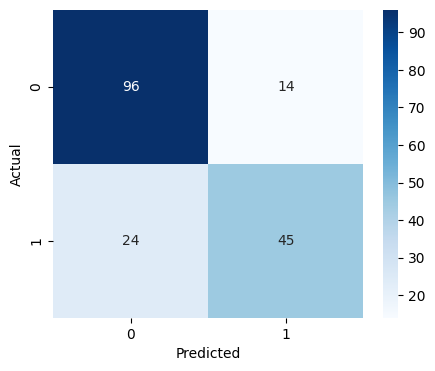

              precision    recall  f1-score   support

           0       0.80      0.87      0.83       110
           1       0.76      0.65      0.70        69

    accuracy                           0.79       179
   macro avg       0.78      0.76      0.77       179
weighted avg       0.79      0.79      0.78       179

Training Accuracy: 0.8426966292134831
Testing Accuracy: 0.8268156424581006


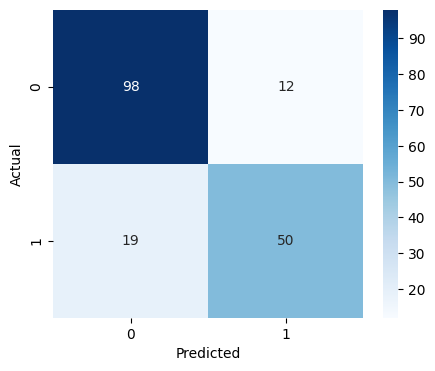

              precision    recall  f1-score   support

           0       0.84      0.89      0.86       110
           1       0.81      0.72      0.76        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.82       179

Training Accuracy: 0.8469101123595506
Testing Accuracy: 0.8268156424581006


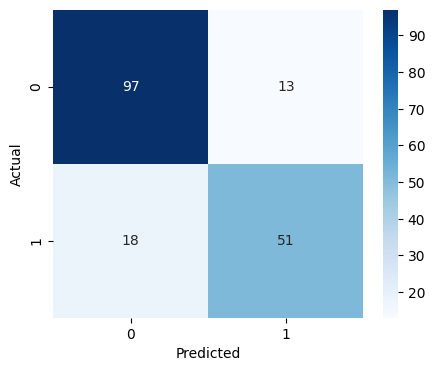

              precision    recall  f1-score   support

           0       0.84      0.88      0.86       110
           1       0.80      0.74      0.77        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.83       179



In [12]:
linear = SVC(kernel="linear", random_state=42)
linear_train, linear_test = evaluate(linear)

poly = SVC(kernel="poly", degree=3, random_state=42)
poly_train, poly_test = evaluate(poly)

rbf = SVC(kernel="rbf", random_state=42)
rbf_train, rbf_test = evaluate(rbf)

In [13]:
X_train_ns, X_test_ns, y_train_ns, y_test_ns = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = SVC(kernel="rbf", random_state=42)

model.fit(X_train_ns, y_train_ns)

pred = model.predict(X_test_ns)

print("Accuracy Without Scaling:", accuracy_score(y_test_ns, pred))
results = pd.DataFrame({
    "Kernel": ["Linear", "Polynomial", "RBF"],
    "Training Accuracy": [linear_train, poly_train, rbf_train],
    "Testing Accuracy": [linear_test, poly_test, rbf_test]
})

results

Accuracy Without Scaling: 0.6201117318435754


,Kernel,Training Accuracy,Testing Accuracy
0,Linear,0.792135,0.787709
1,Polynomial,0.842697,0.826816
2,RBF,0.846910,0.826816
